In [20]:
# Input take label, latent semantics and k
LABEL_INPUT = input(
"""
Provide the label for which you want to find most similar images
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd" if you generated it for tasks where you didn't select the algorithm,
use this format "LS3_color"
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most similar images to find under the latent space."))

In [21]:
from utils.database_utils import retrieve
from utils.distance_utils import find_centroids, top_k_distance_ranker
from scipy.spatial.distance import cityblock, correlation, cosine
from feature_models.feature_matrix.label_label_similarity import LabelLabelSimilarity

In [22]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

Files already downloaded and verified


In [23]:
LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]
FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

# Load created latent space
reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

In [24]:
def find_nearest_cluster(vector, query_vector, K, distance_fn = correlation):
    distance = []
    for i in range(len(vector)):
        distance.append((i, distance_fn(query_vector, vector[i])))
    distance.sort(key=lambda x:x[1])
    return distance[:K]

In [25]:
if LATENT_SPACE != "LS3":
    # For LS1, LS2, LS4, find labels for every image in the latent space
    latent_space = reducer.reduce_features(feature_vectors)
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        label = feature_item[1][0]
        feature = latent_space[i]
        centroid_format_latent_space[i] = (label, feature)

    # Find centroids for the labels
    from utils.vector_utils import get_representative_vectors_for_labels
    from utils.dataset_utils import initialize_dataset

    centroids = get_representative_vectors_for_labels(centroid_format_latent_space, initialize_dataset().categories, 1)

    # Find closest labels based on distance
    distances = find_nearest_cluster(latent_space, centroids[LABEL_INPUT], K)

# For LS3
else:
    # Caleb: Idea
    # Find algorithm to find distance
    # Given images i and get label, cluster it (not sure how to do it)
    # and save centroid
    # For each label in LabelxLabel matrix, find the row of the matching i's label
    # For each column in row of i's label, compare distance with i's label's centroid
    # Sort using numby and get top k results. If we exclude image's label then
    # when calculating distances, make it greater than 0.
    pass

Image Id: 229 

Distance Score: 0.0003774881869593738


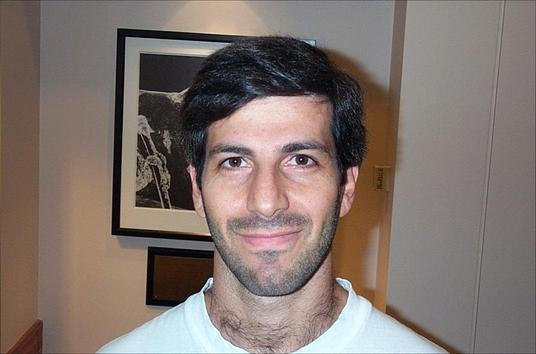

Image Id: 358 

Distance Score: 0.00040499303448227053


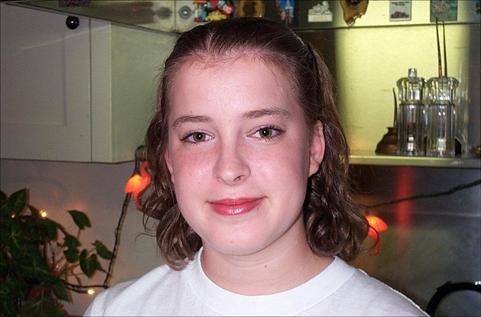

Image Id: 1311 

Distance Score: 0.0006357440486698396


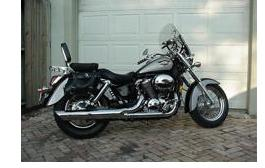

Image Id: 359 

Distance Score: 0.0009771162396710054


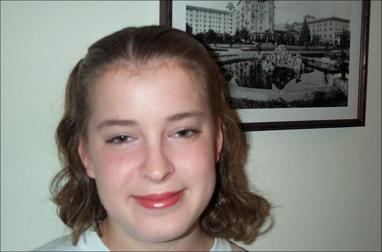

Image Id: 1732 

Distance Score: 0.0011140705506627047


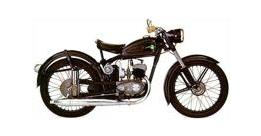

Image Id: 317 

Distance Score: 0.0012846579767609168


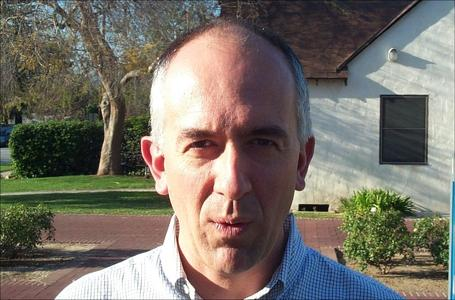

Image Id: 2263 

Distance Score: 0.0014904562114337327


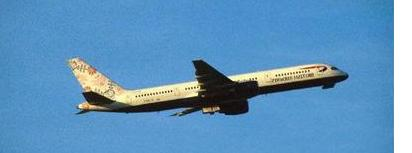

Image Id: 122 

Distance Score: 0.0015092214548829697


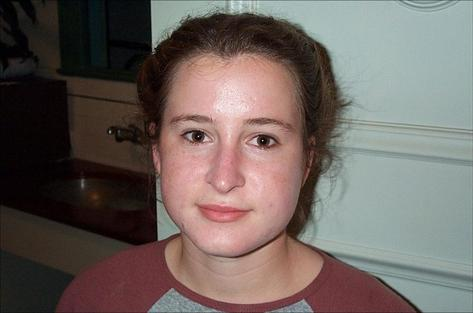

Image Id: 1061 

Distance Score: 0.001639351778433329


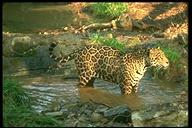

Image Id: 2589 

Distance Score: 0.0017256228555512232


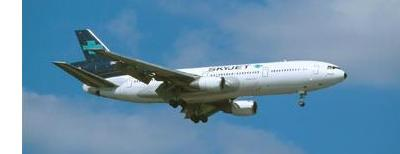

In [26]:
for i in range(len(distances)):
    image_id = distances[i][0]
    distance = distances[i][1]
    print("Image Id:", image_id, "\n\nDistance Score:", distance)
    display(dataset[image_id][0])